Mean Values:
rainfall_mm              754.054667
temperature_c             27.749467
fertilizer_kg            148.744067
irrigation_hours           5.403267
soil_ph                    6.759133
yield_ton_per_hectare      5.028793
dtype: float64

Feature with Highest Mean Value:
rainfall_mm
Highest Mean: 754.0546666666667
rainfall_mm              255.097216
temperature_c              5.758101
fertilizer_kg             56.990279
irrigation_hours           2.584329
soil_ph                    0.719742
yield_ton_per_hectare      0.968282
dtype: float64

Highest Standard Derivation:
rainfall_mm
255.0972161445094


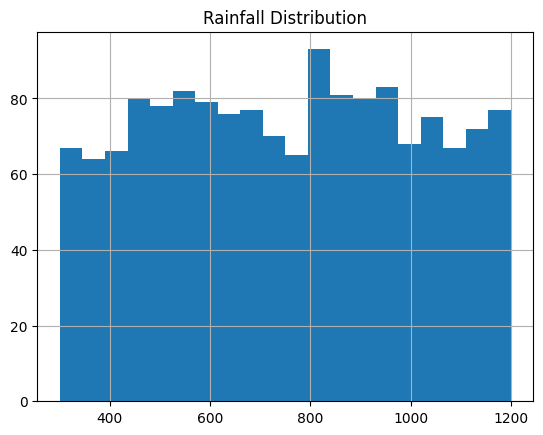

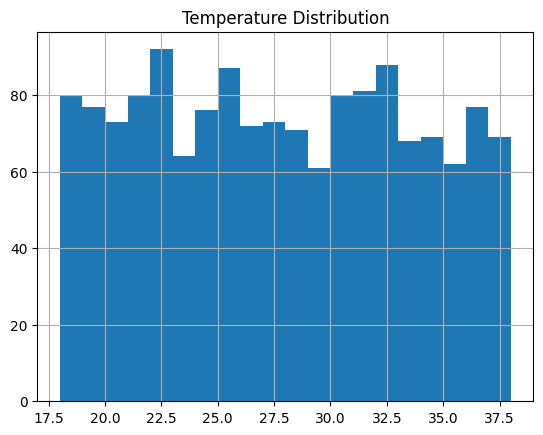

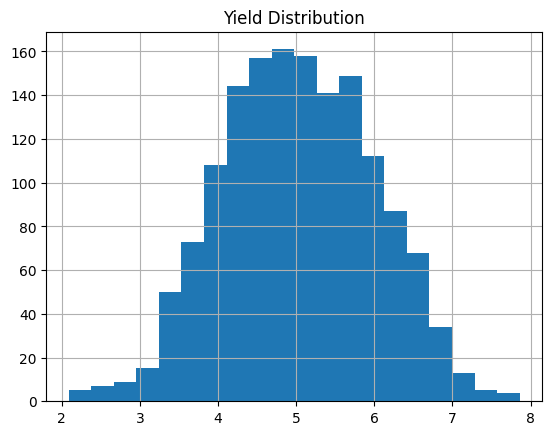

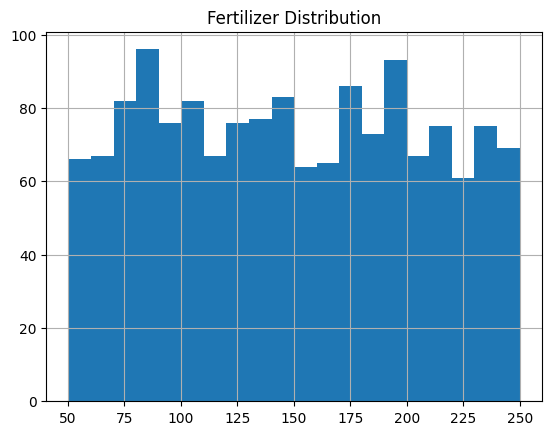

  Crop Type  Number of Records
0    Cotton                311
1   Soybean                306
2     Wheat                303
3      Rice                293
4     Maize                287


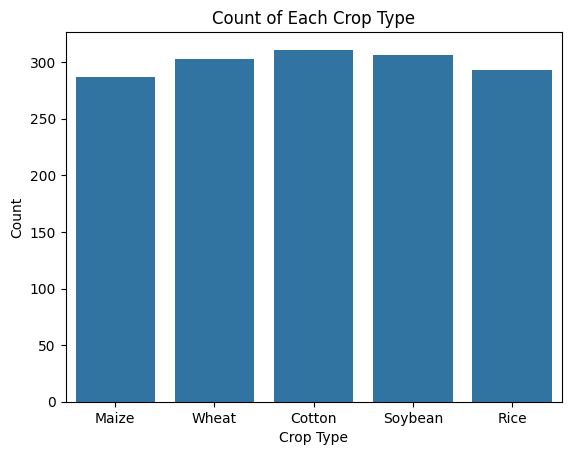

Most Frequent Crop: Cotton
  Soil Type  Frequency
0      Clay        534
1     Sandy        492
2     Loamy        474


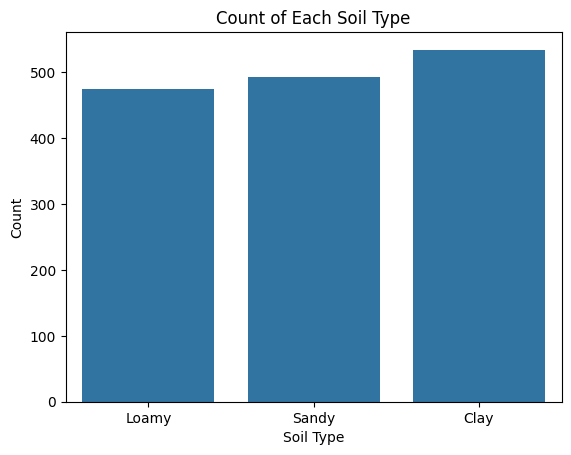

Most Common Soil Type: Clay


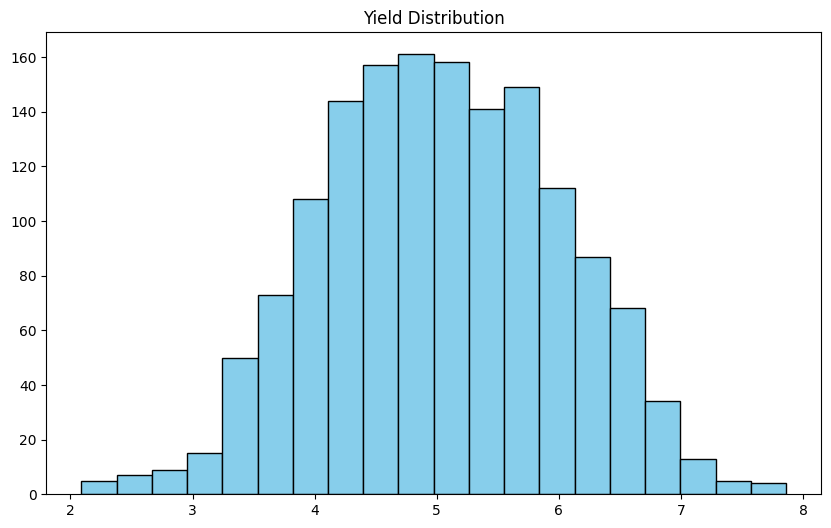

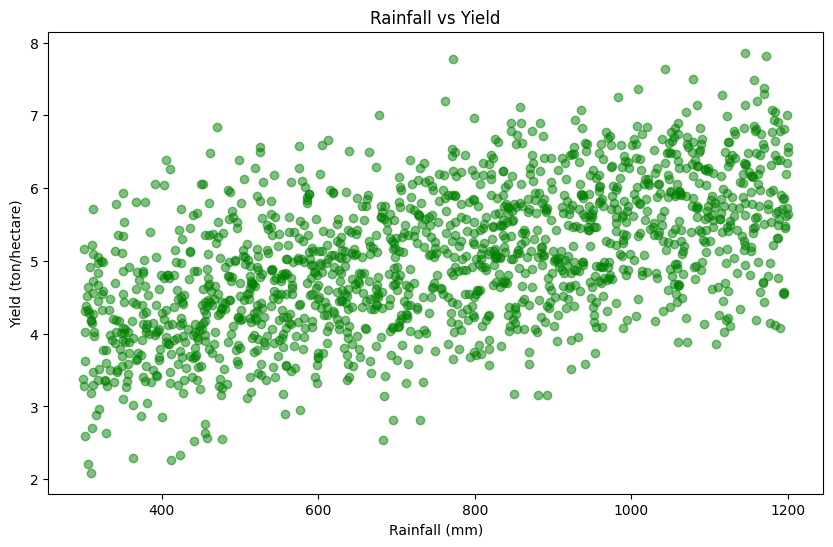

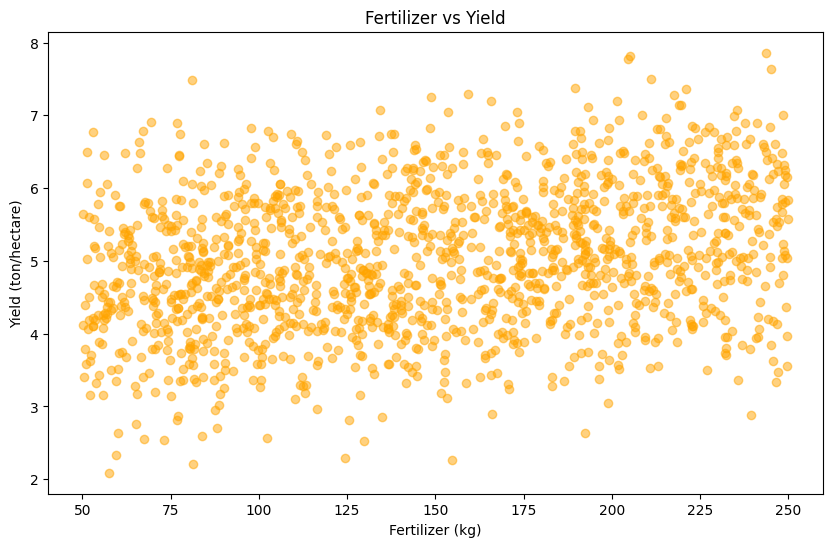


Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

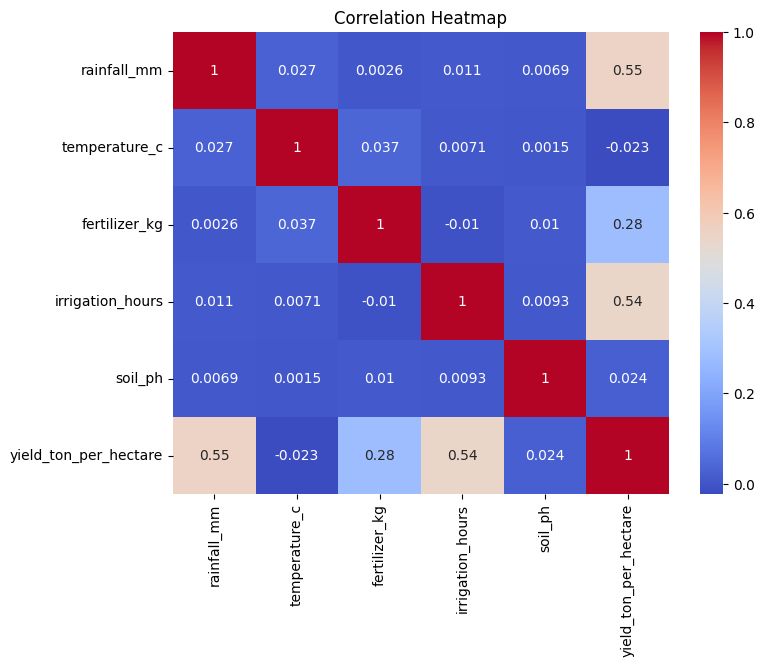


Top Three Most Correlated Features:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1   

In [24]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
# Q1 Load Dataset
df = pd.read_csv("agriculture_yield_dataset.csv")
df.head()
df.shape
df.columns
df.head(10)

#Q2 Data types and missing values
df.dtypes
df.isnull().sum()

#Q3 Descriptive statistics
df.describe()
mean_values=df.mean(numeric_only=True)
print("Mean Values:")
print(mean_values)
highest_mean=mean_values.max()
highest_mean_column=mean_values.idxmax()
print("\nFeature with Highest Mean Value:")
print(highest_mean_column)
print("Highest Mean:",highest_mean)

#highest standard derivation
std_values=df.std(numeric_only=True)
print(std_values)
print("\nHighest Standard Derivation:")
print(std_values.idxmax())
print(std_values.max())

#Q4 Distribution Analysis
df['rainfall_mm'].hist(bins=20)
plt.title("Rainfall Distribution")
plt.show()

#OBSERVATION
1.Values range from about 300-1200mm
2.Distribution is fairly uniform
3.No extreme outliers.


df['temperature_c'].hist(bins=20)
plt.title("Temperature Distribution")
plt.show()

#OBSERVATION
1.Temperature ranges between 18 degree celsius and 38 degree celsius
2.Distribution is approximately symmetric.
3.Most values concentrated around 28 degree celsius.


df['yield_ton_per_hectare'].hist(bins=20)
plt.title("Yield Distribution")
plt.show()

#OBSERVATION
1.Yield ranges from about 2-8 tons/hectare.
2.Distribution is close to normal.
3.Most yields lie between 4 and 6 tons/hectare.

df['fertilizer_kg'].hist(bins=20)
plt.title("Fertilizer Distribution")
plt.show()

#OBSERVATION
1.Fertilizer usage ranges from 50-250kg.
2.Valued are evenly distributed.
3.No significant outliers.


#Q5 Crop type Analysis
#Number of records for each crop type
crop_count=df['crop_type'].value_counts().reset_index()
crop_count.columns=['Crop Type','Number of Records']
print(crop_count)

#Create a count plot(bar chart)for crop_type
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='crop_type',data=df)
plt.title("Count of Each Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

#To find the most frequent crop
most_frequent_crop=df['crop_type'].value_counts().idxmax()
print("Most Frequent Crop:",most_frequent_crop)

#Q6 Soil type Analysis
# frequency of each soil type
soil_frequency=df['soil_type'].value_counts().reset_index()
soil_frequency.columns=['Soil Type','Frequency']
print(soil_frequency)

#Create a count plot for soli_type.
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='soil_type',data=df)
plt.title("Count of Each Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.show()

#most common soil type
most_common_soil=df['soil_type'].value_counts().idxmax()
print("Most Common Soil Type:",most_common_soil)

#Q7 Yield Distribution
#create a histogram yield_ton_per_hectare
plt.figure(figsize=(10,6))
plt.hist(df['yield_ton_per_hectare'],bins=20,color='skyblue',edgecolor='black')
plt.title("Yield Distribution")
plt.show()
1.Distributionis approximately normal.
2.No major outliers are visible.

#Q8 Scatter plot Analysis
#create scatter plot of rainfall_mm vs yield_ton_per_hectare
plt.figure(figsize=(10,6))
plt.scatter(df['rainfall_mm'],df['yield_ton_per_hectare'],color='green',alpha=0.5)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (ton/hectare)")
plt.show()

1. rainfall_mm appears to have a stronger relationship with crop yield.

#create scatter plot of fertilizer_kg vs yield_ton_per_hectare
plt.figure(figsize=(10,6))
plt.scatter(df['fertilizer_kg'],df['yield_ton_per_hectare'],color='orange',alpha=0.5)
plt.title("Fertilizer vs Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield (ton/hectare)")
plt.show()

#Q9 Correlation Analysis
#Generate correlation matrix for numerical feature
numeric_df=df.select_dtypes(include=np.number)
corr_matrix=numeric_df.corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

#Create a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# identify top three feature most correlated with crop yield
top_feature=numeric_df.corr()['yield_ton_per_hectare']\
          .drop('yield_ton_per_hectare')\
          .sort_values(ascending=False)
print("\nTop Three Most Correlated Features:")
print(top_feature.head(3))

#Q10 Group Based Analysis
#Average yield for each crop type
print("\nAverage Yield by Crop Type:")
print(df.groupby('crop_type')['yield_ton_per_hectare'].mean())

#Average yield for each soil type
print("\nAverage Yield by Soil Type:")
print(df.groupby('soil_type')['yield_ton_per_hectare'].mean())

1.Highest crop yield is Rice(5.48 tons/hectare)
2.Highest soil type is Loamy(5.37 tons/hectare)

#Q11 Feature Encoding
#Identify categorical columns
categorical_columns=df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(categorical_columns)

#Convert them into numerical form using hot encoding
df_encoded=pd.get_dummies(
    df,
    columns=['crop_type','soil_type'])
print(df_encoded.head())
print(df_encoded.columns)

#Display first five rows of transformed dataset
df_encoded=pd.get_dummies(
    df,
    columns=['crop_type','soil_type'])
df_encoded.head()

#Q12Feature selection
X=df_encoded.drop('yield_ton_per_hectare',axis=1)
y=df_encoded['yield_ton_per_hectare']
print("\nXShape:",X.shape)
print("y Shape:",y.shape)

1.Target column is yield_ton_per_hectare

#Q13 Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=42)
print("\nX_train Shape:",X_train.shape)
print("X_test Shape:",X_test.shape)
print("y_train Shape:",y_train.shape)
print("y_test Shape:",y_test.shape)

#Q14 Linear Regression Model
model=LinearRegression()
model.fit(X_train,y_train)
print("\nIntercept:")
print(model.intercept_)
coefficients=pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})
print("\nModel Coefficients:")
print(coefficients)
highest_feature=coefficients.loc[coefficients['Coefficient'].idxmax()]
print("\nHighest Positive Coefficient:")
print(highest_feature)